# BAMv3 실험: 노이즈→노이즈 학습

**Ultra-low SNR 환경을 위한 Robust Feature Learning**
- Self-supervised 학습 방식
- 다양한 SNR에서 일관된 패턴 학습
- 병목 효과로 랜덤 노이즈 제거
- 노이즈 범위 줄임(5~-5db)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa, MultiBAMv6
import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)


/home/gwon9906/LoRa-bam-reconstruction/utils/my_lora_utils.py


In [2]:
from scipy.signal import stft, istft

STFT_PARAMS = {
    'nperseg': 128,
    'noverlap': 64,
    'nfft': 512,      
    'window': 'hann'
}

def generate_complex_spectrogram(iq_signal, fs, bw=125_000, norm_params=None, clip_norm=False):
    nperseg  = STFT_PARAMS['nperseg']
    noverlap = STFT_PARAMS['noverlap']
    nfft     = STFT_PARAMS['nfft']
    window   = STFT_PARAMS['window']

    f, t, Zxx = stft(
        iq_signal,
        fs=fs,
        window=window,
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nfft,
        boundary=None,
        padded=False,
        return_onesided=False
    )

    # 주파수축 shift 후 BW 크롭
    f_shifted    = np.fft.fftshift(f)
    Zxx_shifted  = np.fft.fftshift(Zxx, axes=0)
    original_shape = Zxx_shifted.shape

    mask = (f_shifted >= -bw/2) & (f_shifted < bw/2)
    freq_indices = np.where(mask)[0]
    Zxx_cropped  = Zxx_shifted[mask, :]   # (F_bw, T)

    real_part = Zxx_cropped.real
    imag_part = Zxx_cropped.imag

    # ✅ 핵심: norm_params가 주어지면 그걸로 정규화 (clean 기준 스케일 공유)
    if norm_params is None:
        r_min, r_max = real_part.min(), real_part.max()
        i_min, i_max = imag_part.min(), imag_part.max()
    else:
        r_min, r_max = norm_params['r_min'], norm_params['r_max']
        i_min, i_max = norm_params['i_min'], norm_params['i_max']

    real_norm = (real_part - r_min) / (r_max - r_min + 1e-12)
    imag_norm = (imag_part - i_min) / (i_max - i_min + 1e-12)

    # noisy는 clean min/max로 정규화하면 범위 밖으로 나갈 수 있음 → 안정화용 옵션
    if clip_norm:
        real_norm = np.clip(real_norm, -1.0, 2.0)
        imag_norm = np.clip(imag_norm, -1.0, 2.0)

    combined_flat = np.concatenate([real_norm.flatten(), imag_norm.flatten()])

    # norm_params는 “계산한 경우(=clean)”에만 의미있게 반환
    out_norm_params = {
        'r_min': r_min, 'r_max': r_max,
        'i_min': i_min, 'i_max': i_max,
        'shape': Zxx_cropped.shape,
        'original_shape': original_shape,
        'freq_indices': freq_indices,
        'stft_params': STFT_PARAMS.copy(),
        'orig_len': len(iq_signal),
        'bw': bw,
        'fs': fs,
    }

    return combined_flat, out_norm_params

def reconstruct_iq_from_spectrogram(restored_flat, norm_params, fs):
    """
    BAM 복원 스펙트로그램(flat) → complex STFT → ISTFT → IQ 신호
    (재학습 버전용)
    """
    cropped_shape = norm_params['shape']   # (F_bw, T)
    mid = len(restored_flat) // 2

    # 1) Real/Imag 복원 + reshape
    real_restored_norm = restored_flat[:mid].reshape(cropped_shape)
    imag_restored_norm = restored_flat[mid:].reshape(cropped_shape)

    # 2) 역정규화
    real_restored = (
        real_restored_norm * (norm_params['r_max'] - norm_params['r_min'])
        + norm_params['r_min']
    )
    imag_restored = (
        imag_restored_norm * (norm_params['i_max'] - norm_params['i_min'])
        + norm_params['i_min']
    )

    Zxx_cropped = real_restored + 1j * imag_restored   # (F_bw, T)

    # 3) full STFT 행렬로 복원
    Zxx_full = np.zeros(norm_params['original_shape'], dtype=complex)
    Zxx_full[norm_params['freq_indices'], :] = Zxx_cropped

    # 4) ifftshift로 원래 STFT 형태로 되돌림
    Zxx_unshifted = np.fft.ifftshift(Zxx_full, axes=0)

    # 5) ISTFT (STFT와 완전히 동일한 파라미터 사용)
    stft_params = norm_params['stft_params']
    _, iq_restored = istft(
        Zxx_unshifted,
        fs=fs,
        window=stft_params['window'],
        nperseg=stft_params['nperseg'],
        noverlap=stft_params['noverlap'],
        nfft=stft_params['nfft'],
        input_onesided=False,
        boundary=None,
    )

    # 6) 길이 보정 (pad/crop만, resample 사용 ❌)
    target_len = norm_params.get('orig_len', len(iq_restored))

    if len(iq_restored) > target_len:
        iq_restored = iq_restored[:target_len]
    elif len(iq_restored) < target_len:
        iq_restored = np.pad(iq_restored, (0, target_len - len(iq_restored)), mode='edge')

    return iq_restored

In [3]:
# LoRa 파라미터 설정
sf = 9
bw = 125_000  # 250 kHz
OSF = 8
fs = int(bw * OSF)  # 1 MHz

print(f"SF = {sf}, BW = {bw/1e3:.1f} kHz, fs = {fs/1e6:.3f} MHz")

# LoRa 인스턴스 생성 (on-the-fly 노이즈 추가용)
lora = LoRa(sf=sf, bw=bw, OSF=OSF)
fs = lora.fs   # = bw * OSF


SF = 9, BW = 125.0 kHz, fs = 1.000 MHz


In [4]:
########################################
##  1. 클린 IQ 데이터 로드            ##
########################################

base_dir = "dataset_v3_sf9_bw250k"
iq_dir = os.path.join(base_dir, "clean_iq")

print("Loading clean IQ data...")
iq_files = sorted(glob.glob(os.path.join(iq_dir, "*.npy")))
print(f"Found {len(iq_files)} clean IQ files")

# 클린 IQ 로드
iq_data_list = []
for f in iq_files:
    x_clean = np.load(f)  # complex IQ
    iq_data_list.append(x_clean)

X_clean_iq = np.array(iq_data_list)
print(f"Clean IQ shape: {X_clean_iq.shape}, dtype: {X_clean_iq.dtype}")


Loading clean IQ data...
Found 512 clean IQ files
Clean IQ shape: (512, 4096), dtype: complex64


In [5]:
########################################
##  2. 데이터 증강 함수 정의 (Noisy → Clean) ##
########################################

# SNR 범위
SNR_MIN = -7.5
SNR_MAX = 0
AUGMENT_FACTOR = 30  # 각 클린 IQ를 30배로 증강

def augment_dataset(X_clean_iq, augment_factor=30):
    X_noisy_flat_list = []
    X_clean_flat_list = []
    norm_params_list  = []

    num_symbols = len(X_clean_iq)
    print(f"Augmenting {num_symbols} clean IQ symbols × {augment_factor} = {num_symbols * augment_factor} samples")

    for idx, clean_iq in enumerate(X_clean_iq):
        # ✅ clean 기준 스펙트로그램 + norm 파라미터
        clean_flat, clean_norm_params = generate_complex_spectrogram(clean_iq, fs, bw)

        for _ in range(augment_factor):
            snr_db = np.random.uniform(SNR_MIN, SNR_MAX)
            noisy_iq = lora.awgn_iq(clean_iq, snr_db)

            # ✅ noisy도 clean_norm_params를 그대로 적용
            noisy_flat, _ = generate_complex_spectrogram(
                noisy_iq, fs, bw,
                norm_params=clean_norm_params,
                clip_norm=True
            )

            X_noisy_flat_list.append(noisy_flat.astype(np.float32))
            X_clean_flat_list.append(clean_flat.astype(np.float32))
            norm_params_list.append(clean_norm_params)

    X_noisy_flat = np.array(X_noisy_flat_list, dtype=np.float32)
    X_clean_flat = np.array(X_clean_flat_list, dtype=np.float32)

    print(f"Augmented noisy shape: {X_noisy_flat.shape}")
    print(f"Augmented clean shape: {X_clean_flat.shape}")
    print("  - Real/Imag combined (Phase preserved)")
    return X_noisy_flat, X_clean_flat, norm_params_list


print(f"✅ Complex augmentation (Noisy→Clean) defined: {AUGMENT_FACTOR}x per clean IQ")

✅ Complex augmentation (Noisy→Clean) defined: 30x per clean IQ


In [6]:
########################################
##  3. 모델 아키텍처 설정             ##
########################################

# Complex 스펙트로그램 shape 확인을 위한 테스트 (1개만)
test_spec_flat, test_params = generate_complex_spectrogram(X_clean_iq[0], fs, bw)
input_dim = test_spec_flat.shape[0]  # Real + Imag 통합 (2배)

# 점진적 압축: 7936 → 4096 → 3072 → 2048
layers = [input_dim, 4096, 2048, 1024]

print(f"Complex spectrogram shape: {test_params['shape']}")
print(f"Input dim (Real+Imag): {input_dim}")
print(f"Model architecture: {' → '.join(map(str, layers))}")
print(f"Compression ratio: {input_dim / layers[-1]:.1f}x")
print(f"Layers: {len(layers)-1} BAM layers (더 부드러운 압축)")


Complex spectrogram shape: (64, 63)
Input dim (Real+Imag): 8064
Model architecture: 8064 → 4096 → 2048 → 1024
Compression ratio: 7.9x
Layers: 3 BAM layers (더 부드러운 압축)



=== Training MultiBAMv6 Model (Noisy → Clean Complex Spectrogram) ===
Architecture: 8064 → 4096 → 2048 → 1024
Strategy: On-the-fly 30x Augmentation per Epoch (Phase Preserved)

=== Starting Denoising Training (Noisy → Clean) ===
Base samples: 512
Augmentation factor: 30x
Total per epoch: 15360

[VAL] Building fixed validation set (augment=15x) ...
Augmenting 512 clean IQ symbols × 15 = 7680 samples
Augmented noisy shape: (7680, 8064)
Augmented clean shape: (7680, 8064)
  - Real/Imag combined (Phase preserved)
[VAL] Fixed validation samples: 7680

Epoch 1/100
  [Alpha] residual_alpha = 0.1
Augmenting 512 clean IQ symbols × 30 = 15360 samples
Augmented noisy shape: (15360, 8064)
Augmented clean shape: (15360, 8064)
  - Real/Imag combined (Phase preserved)
[v6] Epoch 1/1 | Loss = 0.004018
  [Loss] train=0.004018 | val=0.004021
  👉 New BEST val_loss: 0.004021 (epoch 1)

Epoch 2/100
  [Alpha] residual_alpha = 0.1
Augmenting 512 clean IQ symbols × 30 = 15360 samples
Augmented noisy shape: (

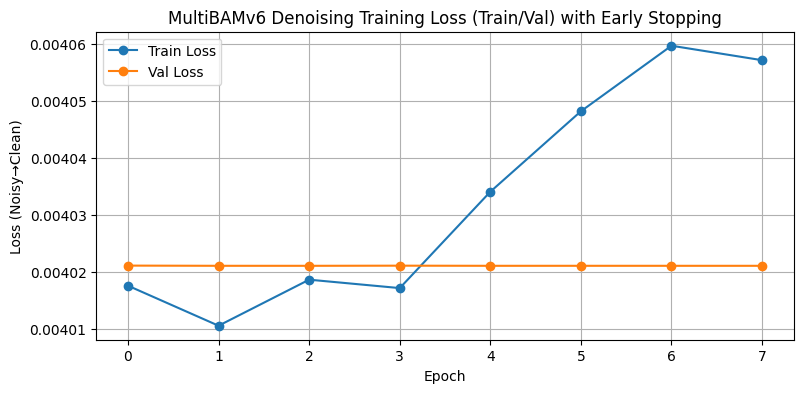


✅ Best model saved to: weights_bamv6_complex/bamv6_complex_best.pt


In [7]:
########################################
##  4. BAMv6 Denoising 학습 + Early Stopping + Best 모델 저장 ##
########################################

import os
import numpy as np
import torch
import copy
import matplotlib.pyplot as plt

print(f"\n=== Training MultiBAMv6 Model (Noisy → Clean Complex Spectrogram) ===")
print(f"Architecture: {' → '.join(map(str, layers))}")
print(f"Strategy: On-the-fly {AUGMENT_FACTOR}x Augmentation per Epoch (Phase Preserved)")

# 🔧 MultiBAMv6 초기화
hidden_dims = layers[1:]
model = MultiBAMv6(
    input_dim=input_dim,
    hidden_dims=hidden_dims,
    activation="leaky_relu",
    use_bn=False,
    residual_alpha=0.1,   # 초기 alpha (아래 스케줄에서 바뀜)
)

TRAIN = True

if TRAIN:
    print("\n=== Starting Denoising Training (Noisy → Clean) ===")
    print(f"Base samples: {len(X_clean_iq)}")
    print(f"Augmentation factor: {AUGMENT_FACTOR}x")
    print(f"Total per epoch: {len(X_clean_iq) * AUGMENT_FACTOR}")

    # 하이퍼파라미터
    num_epochs   = 100
    batch_size   = 64
    lr           = 1e-4
    weight_decay = 0.0

    # 🔹 Early Stopping 하이퍼파라미터 (val_loss 기준)
    patience     = 7
    min_delta    = 1e-4

    # -----------------------------
    # ✅ 고정 Validation set (한 번만 생성)
    # -----------------------------
    VAL_AUGMENT_FACTOR = max(1, AUGMENT_FACTOR // 2)  # 너무 크면 메모리 부담
    print(f"\n[VAL] Building fixed validation set (augment={VAL_AUGMENT_FACTOR}x) ...")
    X_val_noisy, X_val_clean, _ = augment_dataset(X_clean_iq, VAL_AUGMENT_FACTOR)
    print(f"[VAL] Fixed validation samples: {len(X_val_clean)}")

    # -----------------------------
    # ✅ Alpha 스케줄 (옵션)
    # -----------------------------
    # 원하면 구간 조정해도 됨
    def alpha_schedule(ep):
        # ep는 0-based
        if ep < 3:
            return 0.1
        elif ep < 8:
            return 0.3
        else:
            return 0.5

    train_loss_history = []
    val_loss_history   = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state_dict = None
    no_improve_count = 0

    # -----------------------------
    # ✅ val loss 계산 함수 (간단)
    # -----------------------------
    def compute_val_loss(model, Xn, Xc, batch_size=256):
        model.eval()
        criterion = torch.nn.MSELoss(reduction="mean")
        with torch.no_grad():
            Xn_t = model._to_tensor(Xn)
            Xc_t = model._to_tensor(Xc)
            ds = torch.utils.data.TensorDataset(Xn_t, Xc_t)
            dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False)

            total = 0.0
            n = 0
            for noisy_b, clean_b in dl:
                out = model.forward(noisy_b)
                loss = criterion(out, clean_b)
                total += loss.item() * noisy_b.size(0)
                n += noisy_b.size(0)
        model.train()
        return total / max(1, n)

    for epoch in range(num_epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*60}")

        # ✅ alpha 적용
        cur_alpha = alpha_schedule(epoch)
        model.residual_alpha = cur_alpha
        print(f"  [Alpha] residual_alpha = {cur_alpha}")

        # -----------------------------
        # Train set: 매 epoch 새로 증강
        # -----------------------------
        X_noisy_flat, X_clean_flat, _ = augment_dataset(X_clean_iq, AUGMENT_FACTOR)

        # 1 epoch 학습
        hist = model.fit_denoise(
            X_noisy_flat,
            X_clean_flat,
            num_epochs=1,
            batch_size=batch_size,
            lr=lr,
            weight_decay=weight_decay,
            verbose=True
        )

        train_loss = float(hist[-1])
        train_loss_history.append(train_loss)

        # -----------------------------
        # ✅ 고정 val set으로 val loss 측정
        # -----------------------------
        val_loss = compute_val_loss(model, X_val_noisy, X_val_clean, batch_size=256)
        val_loss_history.append(val_loss)

        print(f"  [Loss] train={train_loss:.6f} | val={val_loss:.6f}")

        # -----------------------------
        # ✅ Early Stopping + Best 저장 (val 기준)
        # -----------------------------
        if val_loss + min_delta < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            no_improve_count = 0
            best_state_dict = copy.deepcopy(model.state_dict())
            print(f"  👉 New BEST val_loss: {best_val_loss:.6f} (epoch {epoch+1})")
        else:
            no_improve_count += 1
            print(f"  ⚠ No improvement ({no_improve_count}/{patience})")

        if no_improve_count >= patience:
            print("\n🛑 Early stopping triggered!")
            print(f"Best val_loss: {best_val_loss:.6f} at epoch {best_epoch+1}")
            break

    print("\n=== Training Finished ===")

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(9,4))
    plt.plot(train_loss_history, marker='o', label="Train Loss")
    plt.plot(val_loss_history, marker='o', label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (Noisy→Clean)")
    plt.title("MultiBAMv6 Denoising Training Loss (Train/Val) with Early Stopping")
    plt.grid(True)
    plt.legend()
    plt.show()

    # -----------------------------
    # ✅ Best 모델 저장 (체크포인트)
    # -----------------------------
    if best_state_dict is not None:
        weight_folder = "weights_bamv6_complex"
        os.makedirs(weight_folder, exist_ok=True)

        ckpt_path = os.path.join(weight_folder, "bamv6_complex_best.pt")
        checkpoint = {
            "state_dict": best_state_dict,
            "input_dim": input_dim,
            "hidden_dims": hidden_dims,
            "activation": "leaky_relu",
            "use_bn": False,
            "layers": layers,
            "sf": sf,
            "bw": bw,
            "fs": fs,
            "stft_params": STFT_PARAMS,
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "alpha_schedule": "0.1->0.3->0.5",  # 기록용
            "lr": lr,
            "batch_size": batch_size,
            "augment_factor": AUGMENT_FACTOR,
            "val_augment_factor": VAL_AUGMENT_FACTOR,
        }
        torch.save(checkpoint, ckpt_path)
        print(f"\n✅ Best model saved to: {ckpt_path}")
    else:
        print("\n⚠ best_state_dict is None (training may have been skipped?)")

else:
    print("\nTraining skipped (TRAIN=False)")


In [8]:
########################################
##  5. 모델 저장 (MultiBAMv4)        ##
########################################

import torch
import os
import numpy as np

if TRAIN:
    # 저장 폴더
    weight_folder = "weights_bamv4_complex"
    os.makedirs(weight_folder, exist_ok=True)

    # 🔹 1) PyTorch 체크포인트로 한번에 저장
    ckpt_path = os.path.join(weight_folder, "bamv4_complex_best.pt")

    checkpoint = {
        "state_dict": best_state_dict if 'best_state_dict' in locals() else model.state_dict(),
        "input_dim": input_dim,
        "hidden_dims": hidden_dims,
        "activation": "tanh",
        "layers": layers,
        "sf": sf,
        "bw": bw,
        "fs": fs,
        "stft_params": STFT_PARAMS,
    }

    torch.save(checkpoint, ckpt_path)
    print(f"✅ Best model PyTorch checkpoint saved to: {ckpt_path}")

    # 🔹 2) config npy 저장 (선택)
    config = {
        "input_dim": input_dim,
        "hidden_dims": hidden_dims,
        "activation": "tanh",
        "layers": layers,
        "sf": sf,
        "bw": bw,
        "fs": fs,
        "mode": "complex",
    }
    config_path = os.path.join(weight_folder, "model_config.npy")
    np.save(config_path, config)
    print(f"✅ Config saved to: {config_path}")


print("\n=== How to Load MultiBAMv4 Model ===")
print(r"""
import torch
import numpy as np
from utils.LoRa import MultiBAMv4   # 경로는 너 프로젝트에 맞게

ckpt = torch.load("weights_bamv4_complex/bamv4_complex_best.pt", map_location="cpu")

model = MultiBAMv4(
    input_dim=ckpt["input_dim"],
    hidden_dims=ckpt["hidden_dims"],
    activation=ckpt["activation"],
)
model.load_state_dict(ckpt["state_dict"])
model.eval()
""")

✅ Best model PyTorch checkpoint saved to: weights_bamv4_complex/bamv4_complex_best.pt
✅ Config saved to: weights_bamv4_complex/model_config.npy

=== How to Load MultiBAMv4 Model ===

import torch
import numpy as np
from utils.LoRa import MultiBAMv4   # 경로는 너 프로젝트에 맞게

ckpt = torch.load("weights_bamv4_complex/bamv4_complex_best.pt", map_location="cpu")

model = MultiBAMv4(
    input_dim=ckpt["input_dim"],
    hidden_dims=ckpt["hidden_dims"],
    activation=ckpt["activation"],
)
model.load_state_dict(ckpt["state_dict"])
model.eval()



In [9]:
########################################
##  5-1. 학습된 모델 로드 (TRAIN=False일 때)  ##
########################################

import torch

# TRAIN=False인 경우에만 저장된 모델 로드
if not TRAIN:
    weight_folder = "weights_bamv3_complex"
    
    # Config 파일이 존재하는지 확인
    config_path = os.path.join(weight_folder, "model_config.npy")
    
    if os.path.exists(config_path):
        print(f"\n=== Loading Pre-trained Model ===")
        
        # Config 로드
        config = np.load(config_path, allow_pickle=True).item()
        print(f"Loaded config: {config}")
        
        # 아키텍처가 동일한지 확인
        if config['layers'] == layers:
            # 각 layer의 weight 로드
            for i, bam in enumerate(model.bams):
                weight_path = os.path.join(weight_folder, f"weights_layer_{i}.npy")
                if os.path.exists(weight_path):
                    loaded_weight = np.load(weight_path)
                    # 🔧 디바이스 지정 추가! (CPU/CUDA 자동 감지)
                    bam.W = torch.tensor(loaded_weight, dtype=torch.float32).to(bam.device)
                    print(f"✅ Layer {i} weights loaded from: {weight_path} (device: {bam.device})")
                else:
                    print(f"❌ Warning: {weight_path} not found!")
            
            print(f"✅ Model successfully loaded from {weight_folder}")
        else:
            print(f"❌ Warning: Architecture mismatch!")
            print(f"   Current: {layers}")
            print(f"   Saved:   {config['layers']}")
    else:
        print(f"❌ Warning: No pre-trained model found in {weight_folder}")
        print(f"   Please set TRAIN=True to train a new model first.")
else:
    print("\n=== Using Newly Trained Model ===")
    print("Model weights from training will be used.")



=== Using Newly Trained Model ===
Model weights from training will be used.


In [16]:
import numpy as np

diff = X_val_noisy - X_val_clean
print("Mean abs diff:", np.mean(np.abs(diff)))
print("MSE(noisy, clean):", np.mean(diff**2))
print("Max abs diff:", np.max(np.abs(diff)))
print("P95 abs diff:", np.percentile(np.abs(diff), 95))


Mean abs diff: 0.049106542
MSE(noisy, clean): 0.004021066
Max abs diff: 0.46126148
P95 abs diff: 0.12775835394859314



=== Testing Complex Reconstruction ===
Test symbol: 259, SNR: -10 dB

=== Normalization Parameters ===
Real: min=-1.471774, max=1.336142, range=2.807915
Imag: min=-1.495224, max=1.518056, range=3.013280
Restored norm: real_min=-0.0000, real_max=1.0000
Restored norm: imag_min=-0.0000, imag_max=1.0000
After denorm:  real_min=-1.471850, real_max=1.336051
After denorm:  imag_min=-1.495292, imag_max=1.517968
✅ IQ signal reconstructed: (4096,)
   ✅ Length already matches: 4096 samples
   🔧 Normalized to Unit Power (std=1.0)
   Energy after scaling:  |mean|=0.293599, |max|=46.508970

=== Debug: Values Check ===
Noisy flat:    min=0.0000, max=1.0000, mean=0.5101
Restored flat: min=-0.0000, max=1.0000, mean=0.5101
Difference:    MSE=0.000000


/tmp/ipykernel_224778/780055994.py:106: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, iq_restored = istft(


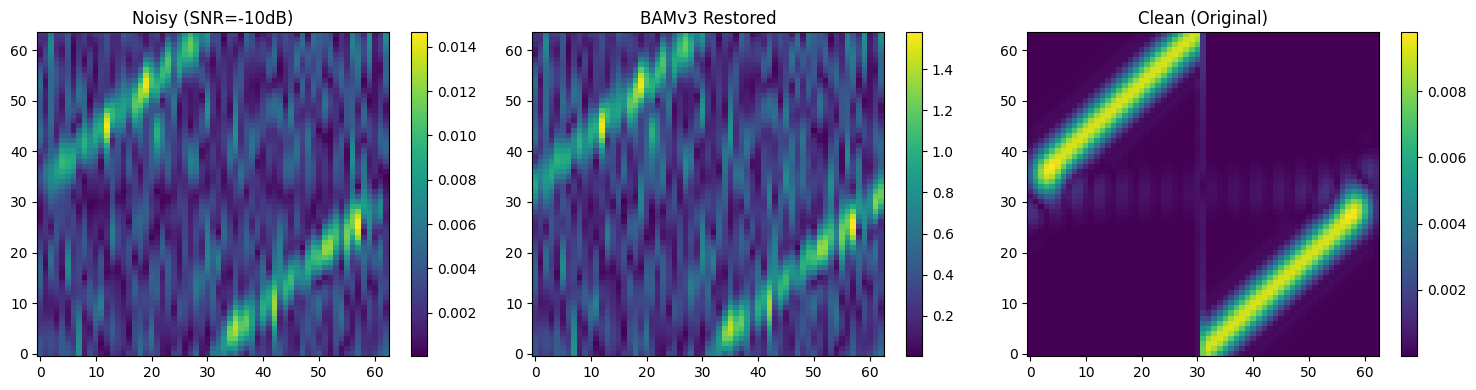


=== Spectrogram Magnitude Check ===
Zxx_noisy (magnitude):    min=0.0000, max=0.0146
Zxx_restored (magnitude): min=0.0020, max=1.5801
Zxx_clean (magnitude):    min=0.0000, max=0.0098


In [15]:
########################################
##  6. 테스트: Complex 복원 및 IQ 재구성  ##
########################################

# 테스트 샘플 선택
test_symbol = 259  # 테스트할 심볼 (0~511)
test_snr = -10    # 테스트 SNR

print(f"\n=== Testing Complex Reconstruction ===")
print(f"Test symbol: {test_symbol}, SNR: {test_snr} dB")

# 1. 클린 IQ 생성
clean_iq = X_clean_iq[test_symbol]

# 2. 노이즈 추가
noisy_iq = lora.awgn_iq(clean_iq, test_snr)

# 3. Complex 스펙트로그램 생성
noisy_flat, norm_params = generate_complex_spectrogram(noisy_iq, fs, bw)

# 4. BAMv4 Denoising 복원
# (1) 직접 Noisy → Clean 재구성
restored_flat = model.reconstruct_numpy(noisy_flat.reshape(1, -1)).flatten()


# 5. Real/Imag 분리 및 역정규화 (학습 시와 동일한 스케일 사용)
mid = len(restored_flat) // 2
real_restored_norm = restored_flat[:mid].reshape(norm_params['shape'])
imag_restored_norm = restored_flat[mid:].reshape(norm_params['shape'])

# 🔍 정규화 파라미터 확인
print(f"\n=== Normalization Parameters ===")
print(f"Real: min={norm_params['r_min']:.6f}, max={norm_params['r_max']:.6f}, range={norm_params['r_max']-norm_params['r_min']:.6f}")
print(f"Imag: min={norm_params['i_min']:.6f}, max={norm_params['i_max']:.6f}, range={norm_params['i_max']-norm_params['i_min']:.6f}")
print(f"Restored norm: real_min={real_restored_norm.min():.4f}, real_max={real_restored_norm.max():.4f}")
print(f"Restored norm: imag_min={imag_restored_norm.min():.4f}, imag_max={imag_restored_norm.max():.4f}")

# 역정규화 (Noisy 범위 사용 - 학습 시와 일관성 유지)
real_restored = real_restored_norm * (norm_params['r_max'] - norm_params['r_min']) + norm_params['r_min']
imag_restored = imag_restored_norm * (norm_params['i_max'] - norm_params['i_min']) + norm_params['i_min']

print(f"After denorm:  real_min={real_restored.min():.6f}, real_max={real_restored.max():.6f}")
print(f"After denorm:  imag_min={imag_restored.min():.6f}, imag_max={imag_restored.max():.6f}")

# 6. Complex 재결합
Zxx_restored = real_restored + 1j * imag_restored

# 7. IQ 신호 복원
iq_reconstructed = reconstruct_iq_from_spectrogram(restored_flat, norm_params, fs)

print(f"✅ IQ signal reconstructed: {iq_reconstructed.shape}")

# -------------------------------------------------------------
# [최종 수정] 길이 보정 및 에너지 정규화
# -------------------------------------------------------------

# 1. 🔧 길이 보정: Resample (필수!)
# 딥러닝 모델 출력(시간축 압축됨)을 원래 LoRa 심볼 길이(2048)로 복원
target_len = len(clean_iq)  # 원본 LoRa symbol 길이 (예: 2048)
cur_len = len(iq_reconstructed)

if cur_len != target_len:
    if cur_len > target_len:
        # 🔪 TRIM: 가운데 부분만 남기기 (시간 정렬 유지)
        diff = cur_len - target_len
        start = diff // 2
        end = start + target_len
        iq_reconstructed = iq_reconstructed[start:end]
        print(f"   🔧 Trimmed: {cur_len} -> {target_len} samples (center slice)")
    else:
        # 🩹 PADDING: 앞/뒤로 0 채우기 (대칭 padding)
        diff = target_len - cur_len
        pad_left = diff // 2
        pad_right = diff - pad_left
        iq_reconstructed = np.pad(
            iq_reconstructed,
            (pad_left, pad_right),
            mode="constant",
            constant_values=0,
        )
        print(f"   🔧 Padded: {cur_len} -> {target_len} samples (zero padding)")
else:
    print(f"   ✅ Length already matches: {target_len} samples")


# 2. ⭐ 에너지 정규화: Standardization (수정됨!)
# 기존(Noisy 에너지 기준)은 위험하므로, 통신 표준인 'Unit Power (std=1)'로 변경
# 이렇게 하면 신호 크기가 적절하게 맞춰져서 디코더가 가장 잘 인식합니다.

iq_std = np.std(iq_reconstructed)

if iq_std > 1e-12:  # 0 나누기 방지 (신호가 살아있는 경우)
    # 평균을 0으로, 표준편차를 1로 맞춤 (Z-score normalization과 유사)
    iq_reconstructed = (iq_reconstructed - np.mean(iq_reconstructed)) / iq_std
    
    print(f"   🔧 Normalized to Unit Power (std=1.0)")
    # 확인용 출력
    print(f"   Energy after scaling:  |mean|={np.abs(iq_reconstructed).mean():.6f}, |max|={np.abs(iq_reconstructed).max():.6f}")

else:
    # 신호가 거의 0인 경우 (복원 실패 또는 무음 구간)
    print(f"   ⚠️ Warning: Reconstructed signal is essentially silence. No scaling applied.")

# -------------------------------------------------------------

# 🔍 디버깅: 값 확인
print(f"\n=== Debug: Values Check ===")
print(f"Noisy flat:    min={noisy_flat.min():.4f}, max={noisy_flat.max():.4f}, mean={noisy_flat.mean():.4f}")
print(f"Restored flat: min={restored_flat.min():.4f}, max={restored_flat.max():.4f}, mean={restored_flat.mean():.4f}")
mse_diff = ((noisy_flat - restored_flat)**2).mean()
print(f"Difference:    MSE={mse_diff:.6f}")

# 시각화: Magnitude 스펙트로그램 비교 (모두 같은 파라미터 + BW 크롭)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Noisy 스펙트로그램 (BW 크롭 적용)
f_n, t_n, Zxx_noisy_full = spectrogram(noisy_iq, fs, window='hann', nperseg=128, noverlap=64, nfft=512, mode='complex', return_onesided=False)
f_n = np.fft.fftshift(f_n)
Zxx_noisy_full = np.fft.fftshift(Zxx_noisy_full, axes=0)
mask_n = (f_n >= -bw/2) & (f_n < bw/2)
Zxx_noisy = Zxx_noisy_full[mask_n, :]
im1 = axes[0].imshow(np.abs(Zxx_noisy), aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title(f'Noisy (SNR={test_snr}dB)')
plt.colorbar(im1, ax=axes[0])

# Restored 스펙트로그램 (이미 크롭됨)
im2 = axes[1].imshow(np.abs(Zxx_restored), aspect='auto', cmap='viridis', origin='lower')
axes[1].set_title('BAMv3 Restored')
plt.colorbar(im2, ax=axes[1])

# Clean 스펙트로그램 (BW 크롭 적용)
f_c, t_c, Zxx_clean_full = spectrogram(clean_iq, fs, window='hann', nperseg=128, noverlap=64, nfft=512, mode='complex', return_onesided=False)
f_c = np.fft.fftshift(f_c)
Zxx_clean_full = np.fft.fftshift(Zxx_clean_full, axes=0)
mask_c = (f_c >= -bw/2) & (f_c < bw/2)
Zxx_clean = Zxx_clean_full[mask_c, :]
im3 = axes[2].imshow(np.abs(Zxx_clean), aspect='auto', cmap='viridis', origin='lower')
axes[2].set_title('Clean (Original)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

# 🔍 스펙트로그램 magnitude 확인
print(f"\n=== Spectrogram Magnitude Check ===")
print(f"Zxx_noisy (magnitude):    min={np.abs(Zxx_noisy).min():.4f}, max={np.abs(Zxx_noisy).max():.4f}")
print(f"Zxx_restored (magnitude): min={np.abs(Zxx_restored).min():.4f}, max={np.abs(Zxx_restored).max():.4f}")
print(f"Zxx_clean (magnitude):    min={np.abs(Zxx_clean).min():.4f}, max={np.abs(Zxx_clean).max():.4f}")


In [11]:
########################################
##  7. Dechirp 및 Code 복원 평가     ##
########################################

from utils.my_lora_utils import estimate_symbol_custom

print("\n=== Dechirp Code Reconstruction Test ===")

# 🔍 IQ 신호 차이 분석
print(f"\n=== IQ Signal Analysis ===")
print(f"Clean IQ:        len={len(clean_iq)}, |mean|={np.abs(clean_iq).mean():.4f}, |max|={np.abs(clean_iq).max():.4f}")
print(f"Noisy IQ:        len={len(noisy_iq)}, |mean|={np.abs(noisy_iq).mean():.4f}, |max|={np.abs(noisy_iq).max():.4f}")
print(f"Reconstructed:   len={len(iq_reconstructed)}, |mean|={np.abs(iq_reconstructed).mean():.4f}, |max|={np.abs(iq_reconstructed).max():.4f}")

# MSE 비교 (길이 맞춤)
min_len = min(len(clean_iq), len(noisy_iq), len(iq_reconstructed))
mse_clean_noisy = np.mean(np.abs(clean_iq[:min_len] - noisy_iq[:min_len])**2)
mse_clean_recon = np.mean(np.abs(clean_iq[:min_len] - iq_reconstructed[:min_len])**2)
mse_noisy_recon = np.mean(np.abs(noisy_iq[:min_len] - iq_reconstructed[:min_len])**2)

print(f"\nMSE Comparison:")
print(f"Clean vs Noisy:        {mse_clean_noisy:.6f}")
print(f"Clean vs Reconstructed: {mse_clean_recon:.6f}")
print(f"Noisy vs Reconstructed: {mse_noisy_recon:.6f}")

# Dechirp 및 심볼 복원 테스트
print(f"\n=== Dechirp Symbol Decoding ===")

# 1. 원본 클린 신호 Dechirp
code_clean, peak_clean = estimate_symbol_custom(clean_iq, sf, fs, bw)
print(f"✅ Clean signal (len={len(clean_iq)})    → Code: {code_clean}, Peak: {peak_clean:.2f}")

# 2. 노이즈 신호 Dechirp
code_noisy, peak_noisy = estimate_symbol_custom(noisy_iq, sf, fs, bw)
print(f"⚠️  Noisy signal (len={len(noisy_iq)})    → Code: {code_noisy}, Peak: {peak_noisy:.2f}")

# 3. BAM 복원 신호 Dechirp (Resample 적용 완료!)
code_restored, peak_restored = estimate_symbol_custom(iq_reconstructed, sf, fs, bw)
print(f"🔧 Restored (len={len(iq_reconstructed)})   → Code: {code_restored}, Peak: {peak_restored:.2f}")

# 성능 평가
print(f"\n{'='*60}")
print(f"Performance Evaluation:")
print(f"{'='*60}")
print(f"Ground Truth Symbol: {test_symbol}")
print(f"Clean Decoded:       {code_clean} {'✅ CORRECT' if code_clean == test_symbol else '❌ WRONG'}")
print(f"Noisy Decoded:       {code_noisy} {'✅ CORRECT' if code_noisy == test_symbol else '❌ WRONG'}")
print(f"Restored Decoded:    {code_restored} {'✅ CORRECT' if code_restored == test_symbol else '❌ WRONG'}")
print(f"{'='*60}")

# Peak 비교
print(f"\nPeak Comparison:")
print(f"Clean Peak:    {peak_clean:.2f}")
print(f"Noisy Peak:    {peak_noisy:.2f} ({peak_noisy/peak_clean*100:.1f}% of clean)")
print(f"Restored Peak: {peak_restored:.2f} ({peak_restored/peak_clean*100:.1f}% of clean)")

if code_restored == test_symbol:
    print(f"\n✅ SUCCESS: BAMv3_huber successfully restored the correct symbol!")
else:
    print(f"\n❌ FAILURE: BAMv3_huber failed to restore the correct symbol")



=== Dechirp Code Reconstruction Test ===

=== IQ Signal Analysis ===
Clean IQ:        len=4096, |mean|=1.0000, |max|=1.0000
Noisy IQ:        len=4096, |mean|=8.9569, |max|=28.6593
Reconstructed:   len=4096, |mean|=0.3080, |max|=43.7996

MSE Comparison:
Clean vs Noisy:        101.311475
Clean vs Reconstructed: 1.829628
Noisy vs Reconstructed: 101.367954

=== Dechirp Symbol Decoding ===
✅ Clean signal (len=4096)    → Code: 259, Peak: 16777215.98
⚠️  Noisy signal (len=4096)    → Code: 259, Peak: 16771266.01
🔧 Restored (len=4096)   → Code: 259, Peak: 125208.62

Performance Evaluation:
Ground Truth Symbol: 259
Clean Decoded:       259 ✅ CORRECT
Noisy Decoded:       259 ✅ CORRECT
Restored Decoded:    259 ✅ CORRECT

Peak Comparison:
Clean Peak:    16777215.98
Noisy Peak:    16771266.01 (100.0% of clean)
Restored Peak: 125208.62 (0.7% of clean)

✅ SUCCESS: BAMv3_huber successfully restored the correct symbol!



📊 QUANTITATIVE PERFORMANCE EVALUATION (Baseline vs BAM)

🧪 Testing with 1000 samples at each SNR level...
SNR levels: [-30, -25, -20, -15, -10, -5] dB


──────────────────────────────────────────────────────────────────────
Testing SNR = -30 dB
──────────────────────────────────────────────────────────────────────


/tmp/ipykernel_224778/780055994.py:106: UserWarning: NOLA condition failed, STFT may not be invertible. Possibly due to missing boundary
  _, iq_restored = istft(


  ✓ Baseline Acc : 7.8%
  ✓ BAM Accuracy : 11.2%

──────────────────────────────────────────────────────────────────────
Testing SNR = -25 dB
──────────────────────────────────────────────────────────────────────
  ✓ Baseline Acc : 52.0%
  ✓ BAM Accuracy : 45.2%

──────────────────────────────────────────────────────────────────────
Testing SNR = -20 dB
──────────────────────────────────────────────────────────────────────
  ✓ Baseline Acc : 99.8%
  ✓ BAM Accuracy : 84.0%

──────────────────────────────────────────────────────────────────────
Testing SNR = -15 dB
──────────────────────────────────────────────────────────────────────
  ✓ Baseline Acc : 100.0%
  ✓ BAM Accuracy : 99.7%

──────────────────────────────────────────────────────────────────────
Testing SNR = -10 dB
──────────────────────────────────────────────────────────────────────
  ✓ Baseline Acc : 100.0%
  ✓ BAM Accuracy : 100.0%

──────────────────────────────────────────────────────────────────────
Testing SNR = -5 dB


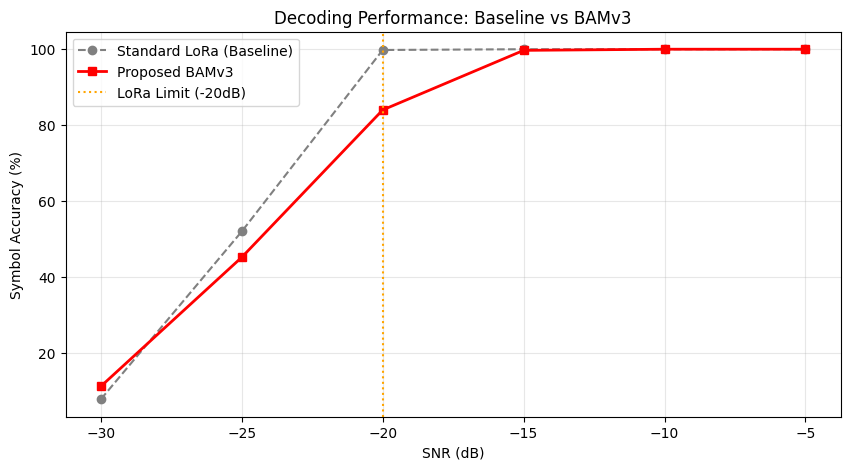

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample

print("\n" + "="*70)
print("📊 QUANTITATIVE PERFORMANCE EVALUATION (Baseline vs BAM)")
print("="*70)

# 1. 테스트 파라미터 설정 ( -30dB 추가 완료 )
NUM_TEST_SAMPLES = 1000  # 샘플 수
TEST_SNR_LEVELS = [-30, -25, -20, -15, -10, -5]  # ⭐ -30dB 추가됨!

# 결과 저장용 딕셔너리
results = {
    snr: {
        'bam_correct': 0, 'bam_total': 0, 'bam_mse': [], 'bam_peak_ratio': [],
        'base_correct': 0, 'base_total': 0, 'base_peak_ratio': [],
    }
    for snr in TEST_SNR_LEVELS
}

print(f"\n🧪 Testing with {NUM_TEST_SAMPLES} samples at each SNR level...")
print(f"SNR levels: {TEST_SNR_LEVELS} dB\n")

for snr in TEST_SNR_LEVELS:
    print(f"\n{'─'*70}")
    print(f"Testing SNR = {snr} dB")
    print(f"{'─'*70}")
    
    for i in range(NUM_TEST_SAMPLES):
        try:
            # 랜덤 심볼 선택
            test_sym = np.random.randint(0, 512)
            
            # 1. 클린 IQ & 노이즈 추가
            clean_iq_test = X_clean_iq[test_sym]
            noisy_iq_test = lora.awgn_iq(clean_iq_test, snr)
            
            # 2. Complex 스펙트로그램 생성
            noisy_flat, noisy_params = generate_complex_spectrogram(noisy_iq_test, fs, bw)
            
            # 4. BAMv4 Denoising 복원
            # (1) 직접 Noisy → Clean 재구성
            restored_flat = model.reconstruct_numpy(noisy_flat.reshape(1, -1)).flatten()
            
            # 4. IQ 신호 재구성 (1차)
            iq_restored = reconstruct_iq_from_spectrogram(restored_flat, noisy_params, fs)

            # ====================================================
            # ⭐ [수정] 길이 보정: Trim / Padding + 에너지 정규화
            # ====================================================
            target_len = len(clean_iq_test)
            cur_len = len(iq_restored)

            # (1) 길이 보정: resample 금지, trim / padding만 사용
            if cur_len != target_len:
                if cur_len > target_len:
                    # 가운데 기준으로 잘라서 타이밍 유지
                    diff = cur_len - target_len
                    start = diff // 2
                    end = start + target_len
                    iq_restored = iq_restored[start:end]
                    # print(f"   🔧 Trimmed: {cur_len} -> {target_len}")
                else:
                    # 부족하면 앞/뒤에 0 패딩 (대칭 padding)
                    diff = target_len - cur_len
                    pad_left = diff // 2
                    pad_right = diff - pad_left
                    iq_restored = np.pad(
                        iq_restored,
                        (pad_left, pad_right),
                        mode="constant",
                        constant_values=0,
                    )
                    # print(f"   🔧 Padded: {cur_len} -> {target_len}")
            # else:
            #     print(f"   ✅ Length already matches: {target_len}")

            # (2) 에너지 정규화 (mean/std 표준화 X, power만 맞춤)
            power = np.mean(np.abs(iq_restored) ** 2)
            if power > 1e-12:
                iq_restored = iq_restored / np.sqrt(power)
            # ====================================================

            # 5. Dechirp 및 심볼 추정 (Baseline vs BAM)
            # 기준: 클린 신호
            code_clean, peak_clean = estimate_symbol_custom(clean_iq_test, sf, fs, bw)
            
            # Baseline: noisy 신호
            code_base, peak_base = estimate_symbol_custom(noisy_iq_test, sf, fs, bw)
            
            # BAM 경로: 복원된 IQ
            code_bam, peak_bam = estimate_symbol_custom(iq_restored, sf, fs, bw)
            
            # -----------------------------
            # 결과 기록
            # -----------------------------
            # 1) Baseline Accuracy
            if code_base == test_sym: results[snr]['base_correct'] += 1
            results[snr]['base_total'] += 1
            
            # 2) BAM Accuracy
            if code_bam == test_sym: results[snr]['bam_correct'] += 1
            results[snr]['bam_total'] += 1
            
            # 3) Peak Ratio
            if peak_clean > 0:
                results[snr]['base_peak_ratio'].append(peak_base / peak_clean)
                results[snr]['bam_peak_ratio'].append(peak_bam / peak_clean)
            
            # 4) MSE (복원 품질)
            # MSE 계산 시에는 크기(Scale) 차이 때문에 정규화된 것끼리 비교하거나, 
            # 단순히 복원력 확인용으로만 참고합니다.
            mse = np.mean(np.abs(iq_restored - clean_iq_test)**2)
            results[snr]['bam_mse'].append(mse)
            
        except Exception as e:
            print(f"  ⚠️ Error at sample {i}: {e}")
            results[snr]['base_total'] += 1
            results[snr]['bam_total'] += 1
    
    # 중간 결과 출력
    base_acc = (results[snr]['base_correct'] / results[snr]['base_total'] * 100) if results[snr]['base_total'] > 0 else 0
    bam_acc = (results[snr]['bam_correct'] / results[snr]['bam_total'] * 100) if results[snr]['bam_total'] > 0 else 0
    
    print(f"  ✓ Baseline Acc : {base_acc:.1f}%")
    print(f"  ✓ BAM Accuracy : {bam_acc:.1f}%")

# 최종 결과 요약 출력 및 그래프 그리기 (기존 코드와 동일)
print("\n" + "="*70)
print("📈 FINAL RESULTS SUMMARY")
print("="*70)
print(f"\n{'SNR':<6} {'Base Acc':<10} {'BAM Acc':<10} {'Improvement':<12}")
print("─"*70)

for snr in TEST_SNR_LEVELS:
    b_acc = results[snr]['base_correct'] / results[snr]['base_total'] * 100
    m_acc = results[snr]['bam_correct'] / results[snr]['bam_total'] * 100
    imp = m_acc - b_acc
    print(f"{snr:<6} {b_acc:>8.1f}%  {m_acc:>8.1f}%  {imp:>+10.1f}%p")

# 그래프 그리기
plt.figure(figsize=(10, 5))
snrs = TEST_SNR_LEVELS
base_accs = [results[s]['base_correct']/results[s]['base_total']*100 for s in snrs]
bam_accs = [results[s]['bam_correct']/results[s]['bam_total']*100 for s in snrs]

plt.plot(snrs, base_accs, 'o--', label='Standard LoRa (Baseline)', color='gray')
plt.plot(snrs, bam_accs, 's-', label='Proposed BAMv3', color='red', linewidth=2)
plt.axvline(x=-20, color='orange', linestyle=':', label='LoRa Limit (-20dB)')

plt.xlabel('SNR (dB)')
plt.ylabel('Symbol Accuracy (%)')
plt.title('Decoding Performance: Baseline vs BAMv3')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
import torch
import numpy as np

def compute_identity_mse(X_noisy, X_clean, batch_size=256, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    Xn = torch.from_numpy(np.asarray(X_noisy, dtype=np.float32)).to(device)
    Xc = torch.from_numpy(np.asarray(X_clean, dtype=np.float32)).to(device)

    ds = torch.utils.data.TensorDataset(Xn, Xc)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False)

    crit = torch.nn.MSELoss(reduction="mean")
    total, n = 0.0, 0

    with torch.no_grad():
        for noisy_b, clean_b in dl:
            # Identity: out = noisy_b
            loss = crit(noisy_b, clean_b)
            total += loss.item() * noisy_b.size(0)
            n += noisy_b.size(0)

    return total / max(1, n)


def compute_model_mse(model, X_noisy, X_clean, batch_size=256):
    model.eval()
    crit = torch.nn.MSELoss(reduction="mean")
    total, n = 0.0, 0

    with torch.no_grad():
        Xn = model._to_tensor(X_noisy)
        Xc = model._to_tensor(X_clean)

        ds = torch.utils.data.TensorDataset(Xn, Xc)
        dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False)

        for noisy_b, clean_b in dl:
            out = model.forward(noisy_b)
            loss = crit(out, clean_b)
            total += loss.item() * noisy_b.size(0)
            n += noisy_b.size(0)

    model.train()
    return total / max(1, n)


# ---- 실행 ----
identity_val_mse = compute_identity_mse(X_val_noisy, X_val_clean, batch_size=256, device=str(model.device))
model_val_mse    = compute_model_mse(model, X_val_noisy, X_val_clean, batch_size=256)

print(f"[VAL] Identity MSE (noisy vs clean): {identity_val_mse:.6f}")
print(f"[VAL] Model    MSE (restored vs clean): {model_val_mse:.6f}")

impr = identity_val_mse - model_val_mse
impr_pct = (impr / identity_val_mse * 100.0) if identity_val_mse > 0 else 0.0
print(f"[VAL] Improvement: {impr:.6f}  ({impr_pct:.2f}%)")


[VAL] Identity MSE (noisy vs clean): 0.004021
[VAL] Model    MSE (restored vs clean): 0.004021
[VAL] Improvement: -0.000000  (-0.00%)


In [14]:
import numpy as np
import torch

model.eval()
with torch.no_grad():
    Xn = model._to_tensor(X_val_noisy)
    out = model.forward(Xn)

delta = (out - Xn).detach().cpu().numpy()
print("Mean |delta|:", np.mean(np.abs(delta)))
print("Max  |delta|:", np.max(np.abs(delta)))
print("Mean delta^2:", np.mean(delta**2))


Mean |delta|: 2.5871306e-05
Max  |delta|: 6.854534e-05
Mean delta^2: 7.5312295e-10
